# Visualizing LeRobot Dataset Validation Results

This notebook visualizes the output of `scripts/validate_lerobot_dataset.py`. 

### Why Validate Robot Data?
Imitation Learning (IL) is fundamentally limited by the quality and consistency of the expert demonstrations. As highlighted in **Russ Tedrake's [Underactuated Robotics (Ch. 21)](https://underactuated.mit.edu/imitation.html)**, IL suffers from **Covariate Shift**: small errors in the policy accumulate, pushing the robot into states never seen during training. If the expert data is noisy or inconsistent, the model cannot learn a robust "manifold" to recover from these errors.

The script generates three main CSV files in the output directory (default: `dataset_validation_results`):
1. `within_episode_d1.csv`: Stationarity results for each dimension and episode.
2. `episode_metrics.csv`: Raw metrics per episode (length, variation, initial state).
3. `across_episode_drift.csv`: Kruskal-Wallis drift test results.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure plots render inline
%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# Results directory: OUT_DIR / RUN_LABEL / RUN_ID
OUT_DIR = Path("../dataset_validation_results")
RUN_LABEL = "default" # The --run-label used in the script
RUN_ID = "run_latest" # Replace with specific run folder (e.g., "run_20260617_143000")

# If you want to automatically point to the latest run for a label:
label_dir = OUT_DIR / RUN_LABEL
if label_dir.exists():
    runs = sorted([d.name for d in label_dir.iterdir() if d.is_dir()])
    if runs:
        RUN_ID = runs[-1]
        print(f"📂 Automatically selected latest run: {RUN_ID}")

RESULTS_PATH = OUT_DIR / RUN_LABEL / RUN_ID
DIFF_ORDER = 1  # Should match the --diff-order used in the script
ALPHA = 0.05    # Significance level
STREAM = "action" # Stream to visualize in heatmap ("action" or "observation.state")

# For Phase 5: Interactive Inspection (LeRobot Dataset)
REPO_ID = "G1_Brainco_PickDrink_Dataset" # Default example, update to your repo ID
DATA_ROOT = Path("../data")
# =============================================================================

📂 Automatically selected latest run: run_20260618_032534


## Load Results

In [4]:
within_path = RESULTS_PATH / f"within_episode_d{DIFF_ORDER}.csv"
metrics_path = RESULTS_PATH / "episode_metrics.csv"
drift_path = RESULTS_PATH / "across_episode_drift.csv"

if not within_path.exists():
    print(f"❌ Could not find {within_path}.")
else:
    df_within = pd.read_csv(within_path)
    print(f"✅ Loaded within-episode results: {len(df_within)} rows")

if not metrics_path.exists():
    print(f"❌ Could not find {metrics_path}. Re-run script to generate.")
else:
    df_metrics = pd.read_csv(metrics_path)
    print(f"✅ Loaded episode metrics: {len(df_metrics)} rows")

if not drift_path.exists():
    print(f"❌ Could not find {drift_path}.")
else:
    df_drift = pd.read_csv(drift_path)
    print(f"✅ Loaded drift results: {len(df_drift)} rows")

✅ Loaded within-episode results: 10452 rows
✅ Loaded episode metrics: 201 rows
✅ Loaded drift results: 183 rows


### Load Raw Dataset (Optional for Inspection)
If you want to use the **Individual Signal Inspector** in Phase 5, ensure your raw LeRobot dataset is accessible at `DATA_ROOT`.

In [5]:
dataset_accessible = False
try:
    from lerobot.datasets.lerobot_dataset import LeRobotDataset
    if (DATA_ROOT / REPO_ID).exists() or (DATA_ROOT / REPO_ID.split('/')[-1]).exists():
        print(f"✅ Dataset {REPO_ID} found at {DATA_ROOT}")
        dataset_accessible = True
    else:
        print(f"⚠️ Dataset {REPO_ID} NOT found at {DATA_ROOT}. Check your REPO_ID and DATA_ROOT in the CONFIGURATION cell.")
except ImportError:
    print("❌ 'lerobot' library not found. Install it with 'pip install lerobot' to use the interactive inspector.")

/workspaces/Isaac-GR00T/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dataset G1_Brainco_PickDrink_Dataset found at ../data


## Phase 1: Signal Smoothness & Stationary Sampling

**Theoretical Context:** In **Cheng Chi's [Diffusion Policy presentation](https://www.youtube.com/watch?v=M03sZFfW-qU&t=129s)**, it is noted that Diffusion Policies learn to denoise expert trajectories. If the expert signal is non-stationary (jittery/noisy), the model may struggle to distinguish between the **expert signal** and the **Gaussian noise** added during the diffusion training process.

We use the **ADF (Augmented Dickey-Fuller)** and **KPSS** tests to ensure that action deltas are stationary. Ideally, robot actions should be **Stationary** or **Difference-Stationary**.

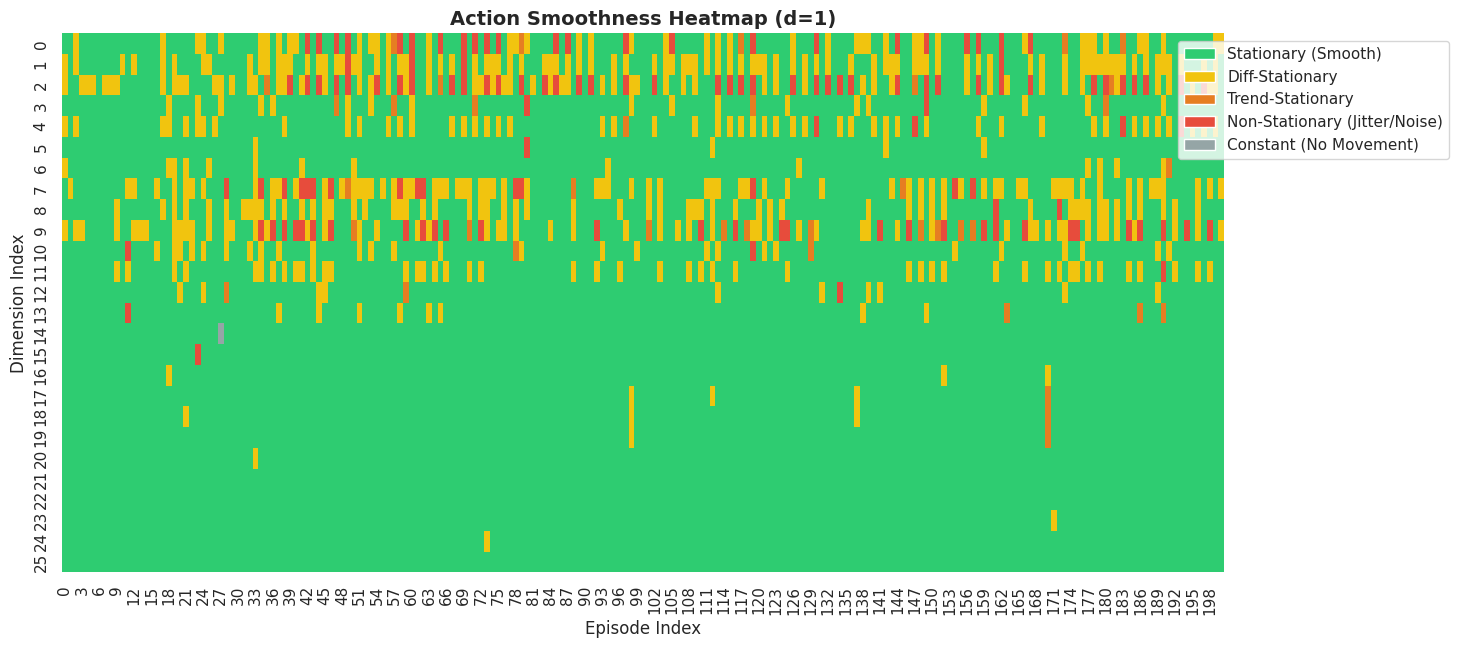

In [6]:
if 'df_within' in locals():
    df_stream = df_within[df_within["stream"] == STREAM].copy()
    
    if not df_stream.empty:
        verdict_map = {"stationary": 0, "difference_stationary": 1, "trend_stationary": 2, "non_stationary": 3, "constant": 4}
        df_stream["verdict_num"] = df_stream["verdict"].map(verdict_map)
        pivot_df = df_stream.pivot(index="dim", columns="episode", values="verdict_num")
        
        plt.figure(figsize=(15, 7))
        cmap = sns.color_palette(["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#95a5a6"])
        sns.heatmap(pivot_df, cmap=cmap, cbar=False, vmin=0, vmax=4)
        
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor="#2ecc71", label="Stationary (Smooth)"),
            Patch(facecolor="#f1c40f", label="Diff-Stationary"),
            Patch(facecolor="#e67e22", label="Trend-Stationary"),
            Patch(facecolor="#e74c3c", label="Non-Stationary (Jitter/Noise)"),
            Patch(facecolor="#95a5a6", label="Constant (No Movement)")
        ]
        plt.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.2, 1))
        plt.title(f"{STREAM.capitalize()} Smoothness Heatmap (d={DIFF_ORDER})", fontsize=14, fontweight="bold")
        plt.xlabel("Episode Index"); plt.ylabel("Dimension Index")
        plt.show()
    else:
        print(f"No data for stream: {STREAM}")

## Phase 2: Episode Metrics Over Time

Checking for trends in trajectory length and movement intensity (variation).

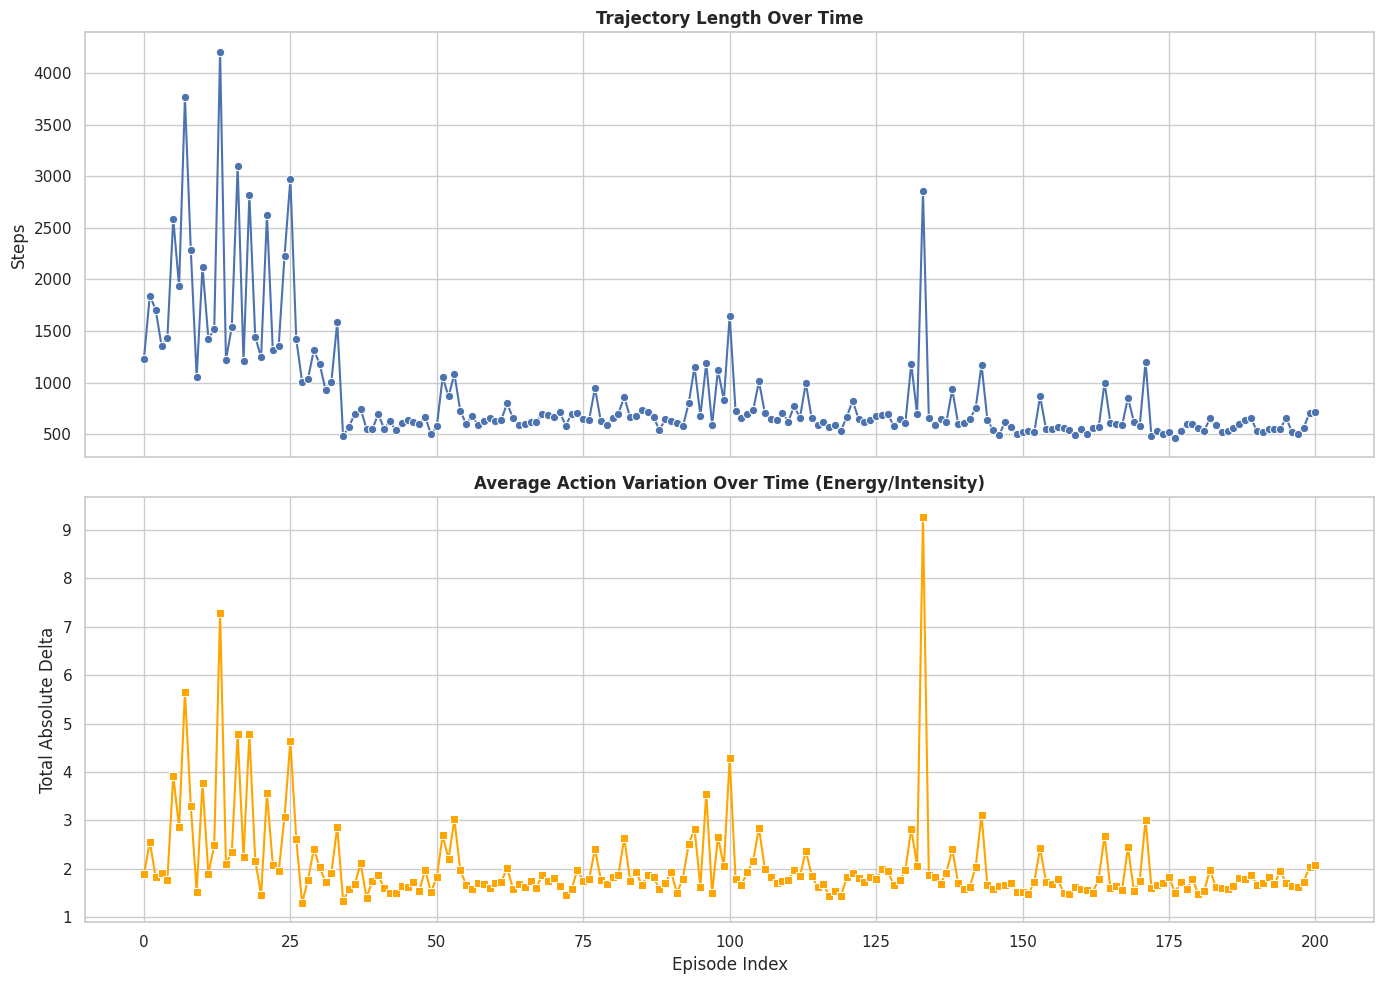

In [7]:
if 'df_metrics' in locals():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Trajectory Length
    sns.lineplot(data=df_metrics, x="episode", y="trajectory_length", ax=ax1, marker="o")
    ax1.set_title("Trajectory Length Over Time", fontweight="bold")
    ax1.set_ylabel("Steps")
    
    # Total Variation (e.g., Action Dimension 0)
    var_cols = [c for c in df_metrics.columns if "var_action" in c]
    if var_cols:
        # Plot mean variation across action dimensions
        df_metrics['mean_action_var'] = df_metrics[var_cols].mean(axis=1)
        sns.lineplot(data=df_metrics, x="episode", y="mean_action_var", ax=ax2, color="orange", marker="s")
        ax2.set_title("Average Action Variation Over Time (Energy/Intensity)", fontweight="bold")
        ax2.set_ylabel("Total Absolute Delta")
    
    plt.xlabel("Episode Index")
    plt.tight_layout()
    plt.show()

## Phase 3: Across-Episode Drift & Distribution Shift

**Theoretical Context:** As discussed in **Russ Tedrake's [Chapter 21](https://underactuated.mit.edu/imitation.html)**, expert trajectories often exhibit drift due to operator fatigue, lighting changes, or hardware degradation. This is a primary driver of **Distribution Shift**. If your training data has significant drift between early and late episodes, the model is trying to learn from a "moving target," which degrades performance on the real robot.

Lower p-values in the Kruskal-Wallis test indicate a higher probability of significant drift between chronological buckets.

/tmp/ipykernel_924/276251187.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_drift_sorted, x="p_value", y="metric", palette=colors)


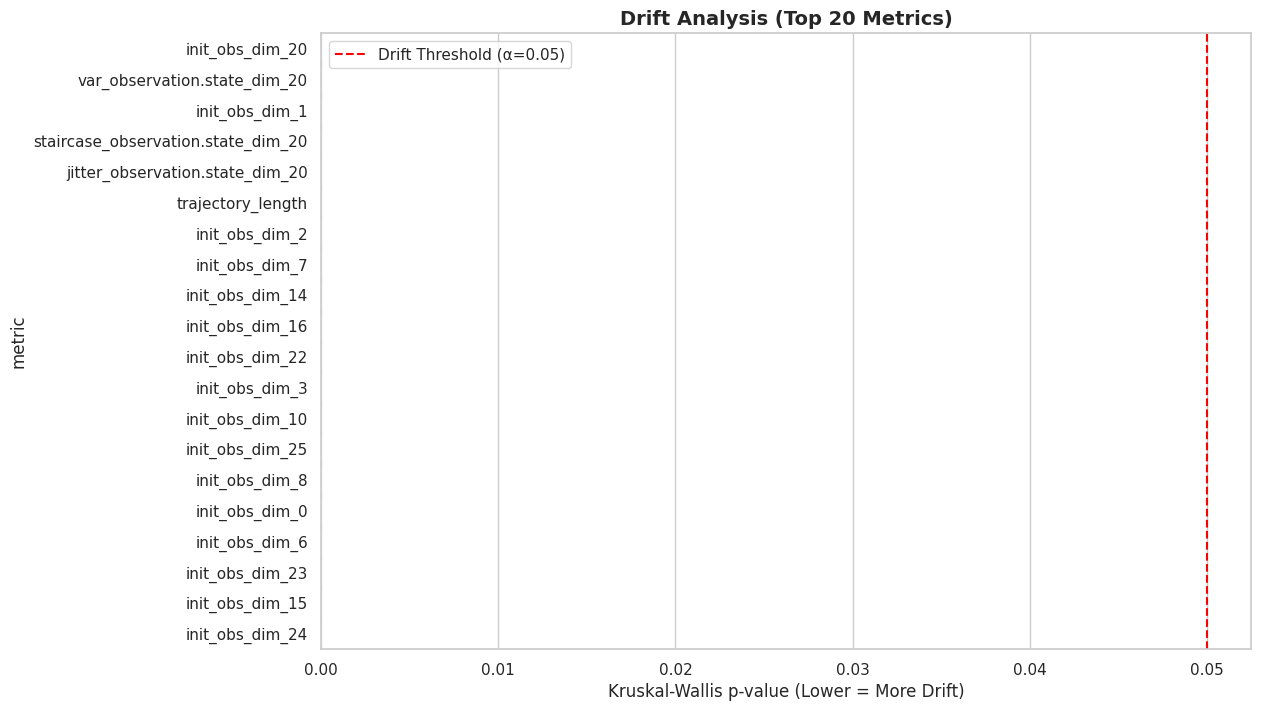

In [8]:
if 'df_drift' in locals() and not df_drift.empty:
    df_drift_sorted = df_drift.sort_values("p_value", ascending=True).head(20)
    
    plt.figure(figsize=(12, 8))
    colors = ["#e74c3c" if p < ALPHA else "#3498db" for p in df_drift_sorted["p_value"]]
    sns.barplot(data=df_drift_sorted, x="p_value", y="metric", palette=colors)
    
    plt.axvline(x=ALPHA, color="red", linestyle="--", label=f"Drift Threshold (α={ALPHA})")
    plt.title("Drift Analysis (Top 20 Metrics)", fontsize=14, fontweight="bold")
    plt.xlabel("Kruskal-Wallis p-value (Lower = More Drift)")
    plt.legend()
    plt.show()

## Phase 4: Dataset Distillation (Weighted Filtering)

We identify episodes to prune based on a weighted quality score to avoid false positives from minor sensor noise:
1. **Systemic Jitter:** Episodes where > 50% of the dimensions are "Non-Stationary." This filters out hardware-wide failures while preserving episodes with minor, single-joint noise.
2. **Hard Outliers:** Episodes with extreme trajectory lengths (outside ±2 standard deviations), which typically indicate failed expert demonstrations (e.g., the robot got stuck or the expert gave up).

In [9]:
if 'df_within' in locals() and 'df_metrics' in locals():
    # 1. Identify systemic jitter (> 50% of dimensions are non_stationary)
    num_dims = df_within["dim"].nunique()
    jitter_counts = df_within[df_within["verdict"] == "non_stationary"].groupby("episode").size()
    systemic_jitter_episodes = jitter_counts[jitter_counts > (num_dims / 2)].index.tolist()
    
    # 2. Identify outliers in trajectory length (e.g., > 2 sigma)
    len_mean = df_metrics["trajectory_length"].mean()
    len_std = df_metrics["trajectory_length"].std()
    outlier_len_episodes = df_metrics[
        (df_metrics["trajectory_length"] > len_mean + 2*len_std) | 
        (df_metrics["trajectory_length"] < len_mean - 2*len_std)
    ]["episode"].tolist()

    # Combine both lists
    all_bad_episodes = sorted(list(set(systemic_jitter_episodes) | set(outlier_len_episodes)))
    
    print(f"Found {len(systemic_jitter_episodes)} episodes with systemic jitter (>50% dims)")
    print(f"Found {len(outlier_len_episodes)} outlier length episodes")
    print(f"---\nTotal unique episodes recommended for pruning: {len(all_bad_episodes)}")
    
    if all_bad_episodes:
        print(f"Episodes: {all_bad_episodes}")
        
        # Generate a command snippet for deletion if desired
        ep_list_str = ",".join(map(str, all_bad_episodes))
        print(f"\nTo prune these, you can use a custom script to filter your LeRobot dataset.")

Found 0 episodes with systemic jitter (>50% dims)
Found 11 outlier length episodes
---
Total unique episodes recommended for pruning: 11
Episodes: [5, 7, 8, 10, 13, 16, 18, 21, 24, 25, 133]

To prune these, you can use a custom script to filter your LeRobot dataset.


## Phase 5: Interactive Signal Analysis & Noise Inspection

In this section, we deep-dive into individual signals to visually inspect jitter and staircase effects. We also apply the **Savitzky-Golay** and **Zero-Phase Low-Pass** filters to see how they improve signal quality.

In [10]:
import sys
from pathlib import Path
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from scripts.apply_filters import apply_savgol_filter, apply_zerophase_lowpass, detect_jitter, detect_staircase
try:
    from lerobot.datasets.lerobot_dataset import LeRobotDataset
except ImportError:
    print("lerobot not found. Signal inspection requires access to the raw dataset.")

### Noise Heatmaps
Visualizing which dimensions and episodes suffer the most from jitter or staircase effects.

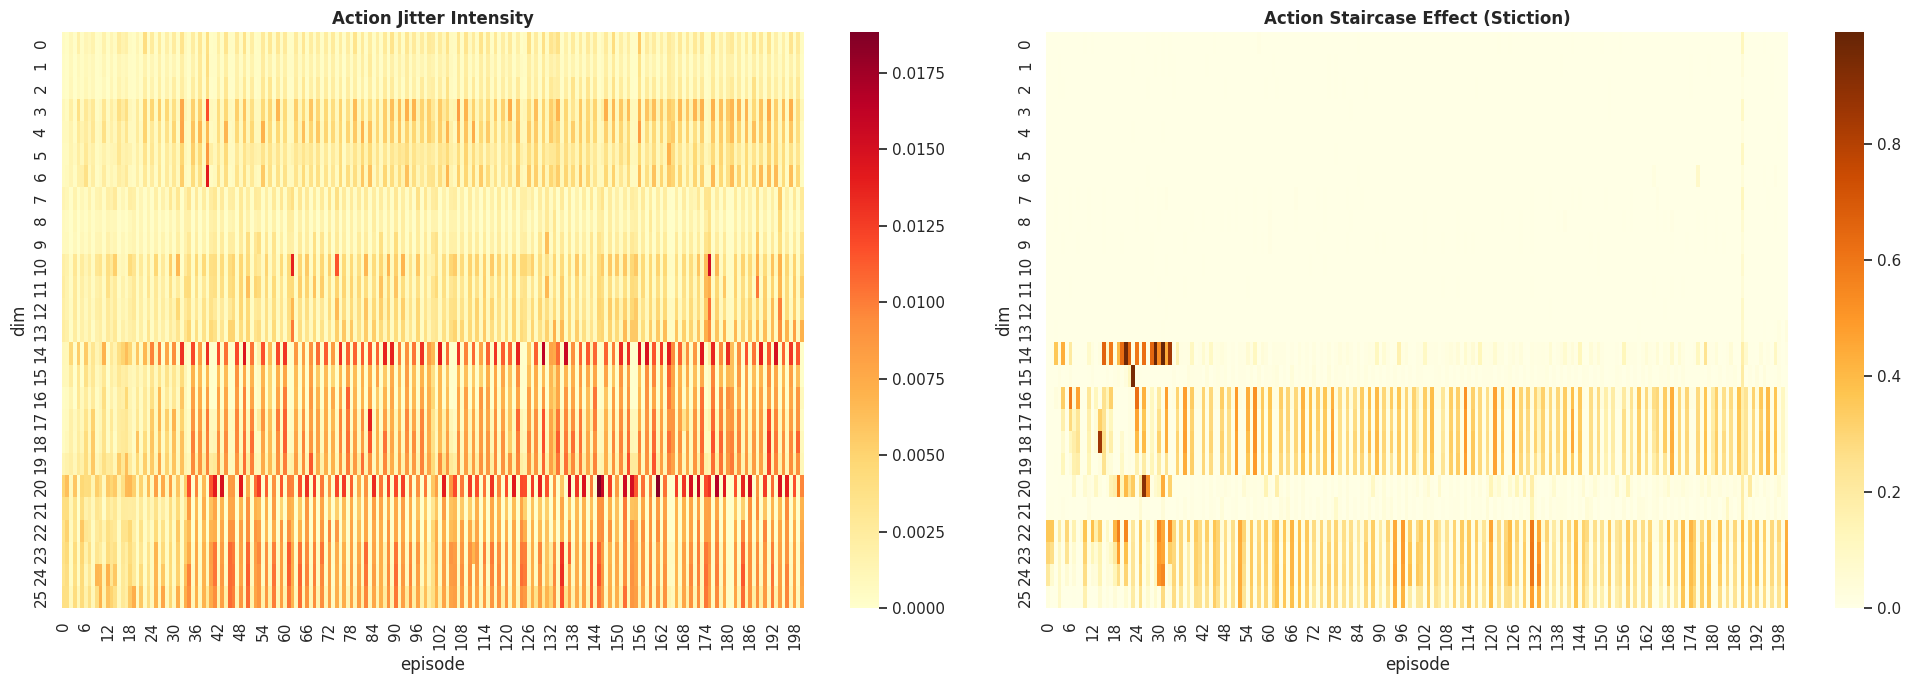

In [11]:
if 'df_within' in locals() and 'jitter' in df_within.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    
    # Jitter Heatmap
    pivot_jitter = df_within[df_within["stream"] == STREAM].pivot(index="dim", columns="episode", values="jitter")
    sns.heatmap(pivot_jitter, cmap="YlOrRd", ax=ax1)
    ax1.set_title(f"{STREAM.capitalize()} Jitter Intensity", fontweight="bold")
    
    # Staircase Heatmap
    pivot_stair = df_within[df_within["stream"] == STREAM].pivot(index="dim", columns="episode", values="staircase")
    sns.heatmap(pivot_stair, cmap="YlOrBr", ax=ax2)
    ax2.set_title(f"{STREAM.capitalize()} Staircase Effect (Stiction)", fontweight="bold")
    
    plt.tight_layout()
    plt.show()

### Individual Signal Inspector

The **Signal Inspector** allows you to perform a "surgical" analysis of specific signals that were flagged as noisy in Phase 1 or the heatmaps above.

#### 📖 How to use:
1. **Identify a target**: Look at the heatmaps or the suggested "worst offenders" below.
2. **Interpret the scores**:
   - **Jitter**: High frequency "buzzing" or oscillation. Often caused by loose hardware or sensor noise.
   - **Staircase**: Flat plateaus followed by jumps. A classic sign of **stiction** (static friction) where the motor is stuck until enough torque accumulates to overcome friction.
3. **Evaluate the Filters**:
   - **Savitzky-Golay**: Best for preserving the "sharpness" of intentional movements while removing high-frequency jitter.
   - **Zero-Phase Lowpass**: Aggressive smoothing. Useful for very noisy sensors but may introduce slight artifacts if the cutoff is too low.
4. **Actionable Insight**: Look at the **Deltas (Velocity Profile)** plot. Neural networks learn these gradients. If the raw deltas are spiky and the filtered ones are smooth, the filtered data will likely lead to a much more stable policy.

In [12]:
def inspect_signal(repo_id, root, ep_idx, dim_idx, stream_key):
    try:
        dataset = LeRobotDataset(repo_id=repo_id, root=root)
    except Exception as e:
        print(f"❌ Error loading dataset: {e}. Ensure REPO_ID and DATA_ROOT are correct in the CONFIGURATION cell.")
        return
    
    # Helper to get episode data
    from_idx = int(dataset.meta.episodes["dataset_from_index"][ep_idx])
    to_idx = int(dataset.meta.episodes["dataset_to_index"][ep_idx])
    data = dataset.hf_dataset.select(range(from_idx, to_idx))[stream_key]
    signal = np.asarray(data, dtype=np.float64)[:, dim_idx]
    
    # Analysis
    jitter = detect_jitter(signal)
    staircase = detect_staircase(signal)
    
    # Filtering
    savgol = apply_savgol_filter(signal, window_length=31, polyorder=3)
    butter_low = apply_zerophase_lowpass(signal, cutoff_freq=2.0, fs=50)
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    t = np.arange(len(signal))
    ax1.plot(t, signal, label="Raw Signal", alpha=0.6, linewidth=2)
    ax1.plot(t, savgol, label="SavGol Filtered", linewidth=2)
    ax1.plot(t, butter_low, label="Zero-Phase Lowpass", linewidth=2, linestyle="--")
    ax1.set_title(f"Signal Inspection: Ep {ep_idx}, {stream_key} Dim {dim_idx}\nJitter: {jitter:.4f} | Staircase: {staircase:.4f}", fontweight="bold")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(t[:-1], np.diff(signal), label="Raw Delta", alpha=0.4)
    ax2.plot(t[:-1], np.diff(savgol), label="SavGol Delta", linewidth=2)
    ax2.set_title("Deltas (Velocity Profile) - What the model learns")
    ax2.set_xlabel("Step Index")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if 'df_within' in locals() and 'jitter' in df_within.columns:
    # Auto-find worst offenders
    worst_jitter = df_within[df_within["stream"] == STREAM].sort_values("jitter", ascending=False).iloc[0]
    worst_staircase = df_within[df_within["stream"] == STREAM].sort_values("staircase", ascending=False).iloc[0]
    
    print(f"🚩 Suggested Inspection (Max Jitter): Episode {worst_jitter['episode']}, Dim {worst_jitter['dim']}")
    print(f"🚩 Suggested Inspection (Max Staircase): Episode {worst_staircase['episode']}, Dim {worst_staircase['dim']}")
    
    # Example Execution
    print("\n--- RUNNING EXAMPLE INSPECTION (Max Jitter Case) ---")
    inspect_signal(REPO_ID, DATA_ROOT, int(worst_jitter['episode']), int(worst_jitter['dim']), STREAM)
else:
    print("❌ Noise metrics not found in results. Re-run scripts/validate_lerobot_dataset.py to generate jitter/staircase scores.")

🚩 Suggested Inspection (Max Jitter): Episode 145, Dim 20
🚩 Suggested Inspection (Max Staircase): Episode 31, Dim 14

--- RUNNING EXAMPLE INSPECTION (Max Jitter Case) ---
❌ Error loading dataset: 401 Client Error. (Request ID: Root=1-6a343607-4caa74bf16c24dda2f83d67a;04bc6765-e3fe-431a-a3f0-19c3135efdd8)

Repository Not Found for url: https://huggingface.co/api/datasets/G1_Brainco_PickDrink_Dataset/refs.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.. Ensure REPO_ID and DATA_ROOT are correct in the CONFIGURATION cell.


## Phase 6: Data Forge (Building Cleaned Datasets)

Once you have identified problematic episodes using the metrics in Phases 1-4 and inspected the noise profiles in Phase 5, you can use the `apply_filters.py` script to forge a new, high-quality dataset for training.

### 📖 How to Use the Dataset Builder
The `apply_filters.py` script allows you to:
1. **Prune Bad Episodes**: Completely remove trajectories that are too short, have extreme outliers, or failed demonstrations using `--drop-episodes`.
2. **Smooth Noisy Signals**: Apply Savitzky-Golay or Butterworth filters to specific episodes to remove hardware jitter/staircase effects while preserving the intent of the movement using `--filter-episodes`.
3. **Blend Datasets**: Append or concatenate specific episodes from other datasets using `--add-repo-id`.

### 🛠️ CLI Flag Reference
- `--repo-id`: (Required) Primary source LeRobot dataset repository identifier.
- `--out-repo-id`: (Required) Output target repository identifier for your cleaned/new dataset.
- `--root`: Local data directory path where datasets are stored (Default: `../data`).
- `--drop-episodes`: Comma-separated list/ranges of episodes to completely remove (e.g., `12,14,20-25`).
- `--filter-episodes`: Comma-separated list/ranges of episodes to apply filters on (e.g., `1,2,5-10` or `all`).
- `--filter-keys`: Comma-separated dataset features to smooth (Default: `action`).
- `--add-repo-id`: Optional secondary dataset repository identifier to append episodes from.
- `--add-episodes`: Specific episodes from the secondary dataset to append (Default: `all`).
- `--filter-type`: Time-series smoothing algorithm selection (`savgol` or `butterworth`).
- `--window-length`: Savitzky-Golay window size. Must be an odd integer (Default: `31`).
- `--polyorder`: Savitzky-Golay polynomial degree parameter (Default: `3`).
- `--cutoff-freq`: Butterworth low-pass cutoff frequency in Hz (Default: `2.0`).
- `--fs`: Data frame rate / sampling frequency specification in Hz (Default: `50.0`).

### Running from the Notebook
You can run the script directly from this notebook using `!uv run`. This ensures all dependencies (like `lerobot`) are correctly loaded.

**Note on Paths**: Since this notebook is in `getting_started/`, we use `../scripts/apply_filters.py` to target the script relatively.

In [14]:
!uv run --isolated \
--with "lerobot @ git+https://github.com/huggingface/lerobot.git@c75455a6de5c818fa1bb69fb2d92423e86c70475" \
--with statsmodels --with pandas --with scipy --with tqdm --with matplotlib --with seaborn \
python ../scripts/apply_filters.py \
--repo-id G1_Brainco_PickDrink_Dataset \
--out-repo-id G1_Brainco_PickDrink_Cleaned \
--help

Installed 137 packages in 1.29s                             
⠙ pydantic-core==2.41.5                                                         usage: apply_filters.py [-h] --repo-id REPO_ID [--root ROOT] --out-repo-id
                        OUT_REPO_ID [--filter-episodes FILTER_EPISODES]
                        [--drop-episodes DROP_EPISODES]
                        [--filter-keys FILTER_KEYS]
                        [--add-repo-id ADD_REPO_ID]
                        [--add-episodes ADD_EPISODES]
                        [--filter-type {savgol,butterworth}]
                        [--window-length WINDOW_LENGTH]
                        [--polyorder POLYORDER] [--cutoff-freq CUTOFF_FREQ]
                        [--fs FS]

Advanced Interactive Dataset Builder and Time-Series Filter CLI.

options:
  -h, --help            show this help message and exit
  --repo-id REPO_ID     Primary source LeRobot dataset repo ID.
  --root ROOT           Local data root directory path.
  --out-repo-id OUT